In [1]:
path = r'C:\Users\howel\OneDrive\NYC_CitiBike_Project'

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load your cleaned data with the new columns
# Updated loading code to handle mixed data types
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'citibike_cleaned.csv'), low_memory=False)

Hypothesis: "The further the trip distance (ride_distance_km), the longer the trip duration (ride_duration_min) will be. I expect a positive linear relationship.

In [3]:
# 1. Convert timestamps
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# 2. Create the Duration column
df['ride_duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# 3. Create the Distance column
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return c * 6371
    
df['ride_distance_km'] = haversine(df['start_lat'], df['start_lng'], df['end_lat'], df['end_lng'])

# 4. Filter for clean data (removes trips with 0 distance/time)
df = df[(df['ride_duration_min'] > 0) & (df['ride_distance_km'] > 0)]

# Verify the columns are now there
print(df.columns)

Index(['Unnamed: 0', 'ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_duration_min', 'ride_distance_km'],
      dtype='object')


In [4]:
# Reshape into NumPy arrays
X = df['ride_distance_km'].values.reshape(-1,1)
y = df['ride_duration_min'].values.reshape(-1,1)

# Split into Training (70%) and Test (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

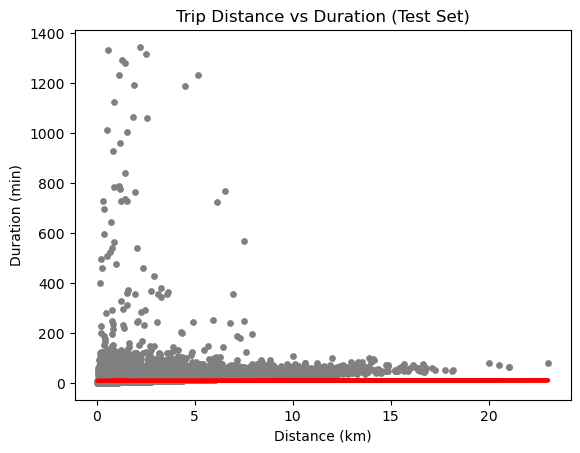

In [5]:
# Fit the model
regression = LinearRegression()
regression.fit(X_train, y_train)

# Predict y based on X_test
y_predicted = regression.predict(X_test)

# Plot the regression line over the test data
plt.scatter(X_test, y_test, color='gray', s=15)
plt.plot(X_test, y_predicted, color='red', linewidth=3)
plt.title('Trip Distance vs Duration (Test Set)')
plt.xlabel('Distance (km)')
plt.ylabel('Duration (min)')
plt.show()

In [6]:
# Calculate statistics
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

print('Slope:' ,regression.coef_)
print('Mean squared error: ', rmse)
print('R2 score: ', r2)

# Compare actual vs predicted values
df_compare = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_predicted.flatten()})
df_compare.head(10)

Slope: [[0.07833493]]
Mean squared error:  180.03119289454526
R2 score:  0.00748147653631992


,Actual,Predicted
0,22.927200,9.627919
1,6.481317,9.608747
2,4.876767,9.608199
3,3.129517,9.573157
4,7.881300,9.573841
5,2.586433,9.539393
6,3.469033,9.568764
7,4.281700,9.564521
8,1.684350,9.534273
9,13.743567,9.904525


1. Visual Interpretation (Hypothesis Test)

The scatterplot shows a dense cluster of trips at low distances and durations, but the red regression line appears almost flat. This indicates that the model is struggling to find a clear linear relationship. While my hypothesis predicted that more distance would lead to more time, the visual shows many 'vertical outliers'—trips with very low distance but extremely high duration (some exceeding 1,200 minutes).

2. Statistical Performance (R2 and MSE)

R2 Score (0.007): This score is very low, meaning the model explains less than 1% of the variance in trip duration. It confirms that a simple linear model is a poor fit for this specific relationship in its current state.

MSE (180.03): The Mean Squared Error is quite high, indicating a large average distance between the predicted values and the actual ride times.

3. Comparison of Actual vs. Predicted

In the comparison dataframe, the model predicted a duration of approximately 9.6 minutes for almost every trip, while actual durations varied wildly from 1.6 to nearly 23 minutes in just the first 10 rows. This further proves the model is currently 'underfitting' the data.

4. Reflections on Data Bias and Outliers

The extreme outliers seen in the scatterplot (trips lasting 1,000+ minutes for only 1–2 km) are likely biasing the model. These likely represent bikes that were not docked correctly or users who kept a bike out all day without traveling a far distance. Because I did not remove these extreme values to avoid distorting reality, the model remains inaccurate. Additionally, the seasonal bias of February may mean many short, erratic trips that don't follow a standard speed pattern.